# Customer Churn Analysis

## Dataset Preview

The IBM Telco Customer Churn dataset contains customer demographic information, service details, contract information, billing data, satisfaction scores, and churn-related attributes. The dataset consists of 7,043 customer records and 50 features used to analyze customer churn behavior and identify factors affecting customer retention.

In [1]:
import pandas as pd

df = pd.read_csv('TelcoCustomerChurn.csv')

df.head()

,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,...,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [2]:
print("Rows and Columns:", df.shape)

Rows and Columns: (7043, 50)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     7043 non-null   object 
 1   Gender                         7043 non-null   object 
 2   Age                            7043 non-null   int64  
 3   Under30                        7043 non-null   object 
 4   SeniorCitizen                  7043 non-null   object 
 5   Married                        7043 non-null   object 
 6   Dependents                     7043 non-null   object 
 7   NumberofDependents             7043 non-null   int64  
 8   Country                        7043 non-null   object 
 9   State                          7043 non-null   object 
 10  City                           7043 non-null   object 
 11  ZipCode                        7043 non-null   int64  
 12  Latitude                       7043 non-null   f

In [4]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Under30,0
SeniorCitizen,0
Married,0
Dependents,0
NumberofDependents,0
Country,0
State,0


In [5]:
df.describe()

,Age,NumberofDependents,ZipCode,Latitude,Longitude,Population,Number_of_Referrals,TenureinMonths,AvgMonthlyLongDistanceCharges,AvgMonthlyGBDownload,MonthlyCharge,TotalCharges,TotalRefunds,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,ChurnScore,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


## Data Understanding

The dataset contains 7,043 customer records and 50 features related to demographics, services, billing, customer satisfaction, and churn behavior. Missing values are primarily present in Offer, InternetType, ChurnCategory, and ChurnReason columns, which is expected because these fields are applicable only to specific customer groups. Summary statistics provide insights into customer age, tenure, charges, revenue, satisfaction scores, and churn-related metrics.

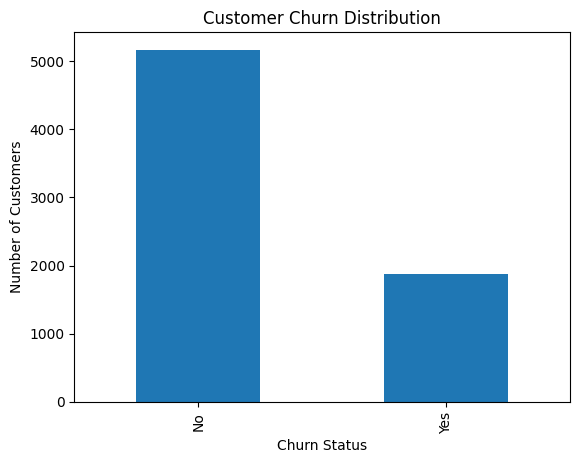

In [6]:
import matplotlib.pyplot as plt

df['ChurnLabel'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.show()

**Observation:** The majority of customers have remained with the company, while approximately 26.54% of customers have churned. This indicates that customer retention is generally strong, but a significant portion of customers still leave the company, making churn analysis important.

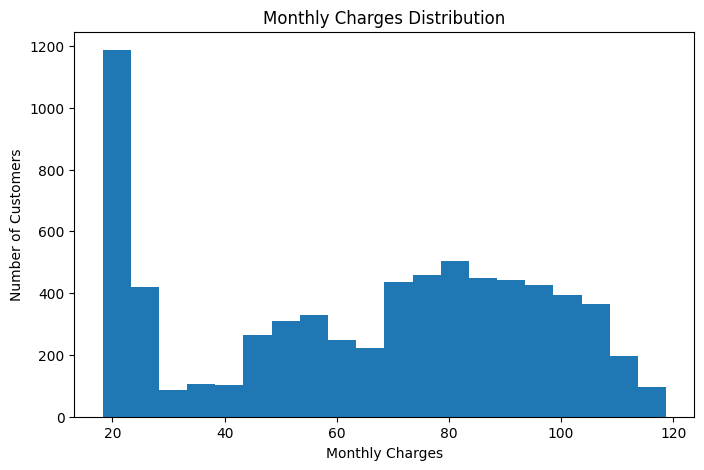

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['MonthlyCharge'], bins=20)

plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')

plt.show()

**Observation:** Monthly charges are distributed across a wide range of values, with a large number of customers paying between ₹70 and ₹100 per month. Higher monthly charges may influence customer churn and should be further analyzed alongside churn status.

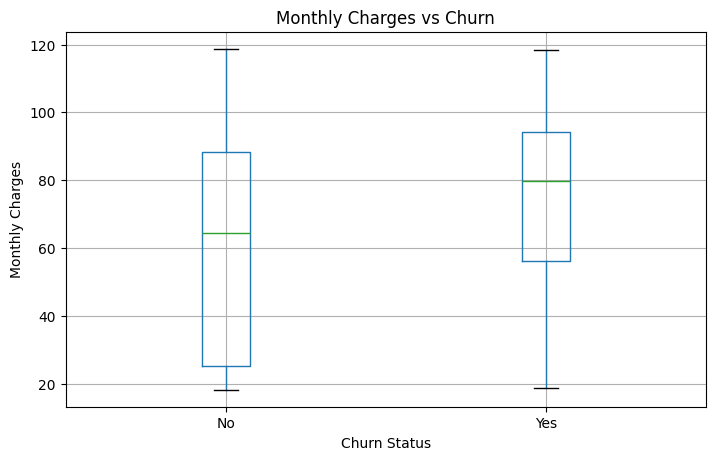

In [8]:
import matplotlib.pyplot as plt

df.boxplot(column='MonthlyCharge', by='ChurnLabel', figsize=(8,5))

plt.title('Monthly Charges vs Churn')
plt.suptitle('')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges')

plt.show()

**Observation:** Customers who churned generally have higher monthly charges compared to customers who stayed with the company. This suggests that higher service costs may contribute to customer churn and should be considered when designing retention strategies.

In [10]:
print("Dataset Shape:", df.shape)

print("\nTotal Customers:", len(df))

print("\nChurn Distribution:")
print(df['ChurnLabel'].value_counts())

print("\nContract Types:")
print(df['Contract'].value_counts())

Dataset Shape: (7043, 50)

Total Customers: 7043

Churn Distribution:
ChurnLabel
No     5174
Yes    1869
Name: count, dtype: int64

Contract Types:
Contract
Month-to-Month    3610
Two Year          1883
One Year          1550
Name: count, dtype: int64


## Dataset Summary

The dataset contains 7,043 customer records and 50 features. Out of all customers, 1,869 customers have churned while 5,174 customers have remained with the company. Month-to-Month contracts are the most common contract type, followed by Two-Year and One-Year contracts.

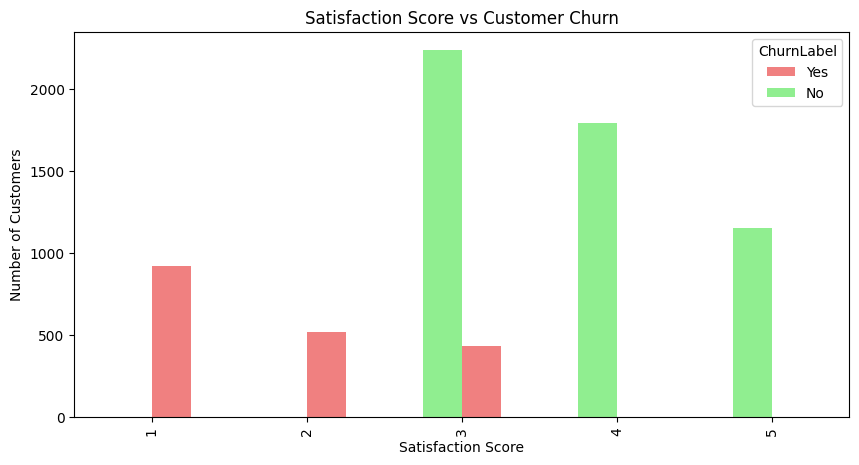

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

satisfaction_churn = pd.crosstab(df['SatisfactionScore'], df['ChurnLabel'])

ax = satisfaction_churn.plot(
    kind='bar',
    figsize=(10,5),
    color=['lightgreen', 'lightcoral']
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='ChurnLabel')

plt.title('Satisfaction Score vs Customer Churn')
plt.xlabel('Satisfaction Score')
plt.ylabel('Number of Customers')

plt.show()

**Observation:** Customers with low satisfaction scores (1 and 2) exhibit the highest churn counts, whereas customers with higher satisfaction scores (4 and 5) show very low churn rates. This indicates that customer satisfaction is a major factor influencing customer retention and churn behavior.

In [12]:
churn_rate = (df['ChurnLabel'].value_counts()['Yes'] / len(df)) * 100

print(f"Customer Churn Rate: {churn_rate:.2f}%")

Customer Churn Rate: 26.54%


## Churn Rate Analysis

The overall customer churn rate is 26.54%, indicating that approximately one out of every four customers has left the company. This highlights the importance of identifying churn drivers and implementing effective customer retention strategies.

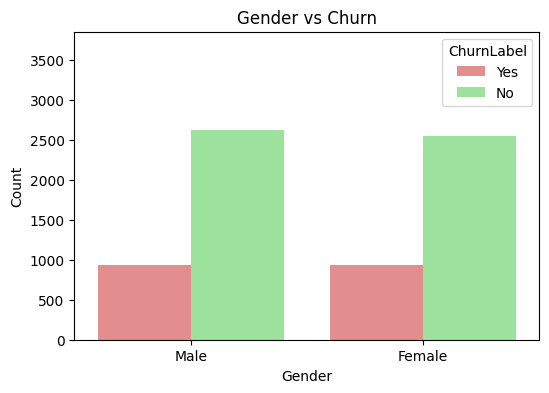

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    'Yes': 'lightcoral',
    'No': 'lightgreen'
}

plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='Gender',
    hue='ChurnLabel',
    data=df,
    palette=palette
)

plt.title('Gender vs Churn')
plt.xlabel('Gender')
plt.ylabel('Count')

# Extra space above bars
plt.ylim(0, ax.get_ylim()[1] * 1.40)

plt.legend(
    title='ChurnLabel',
    loc='upper right'
)

plt.show()

Observation: Churn behavior is similar across male and female customers, indicating that gender is not a major factor influencing customer churn.

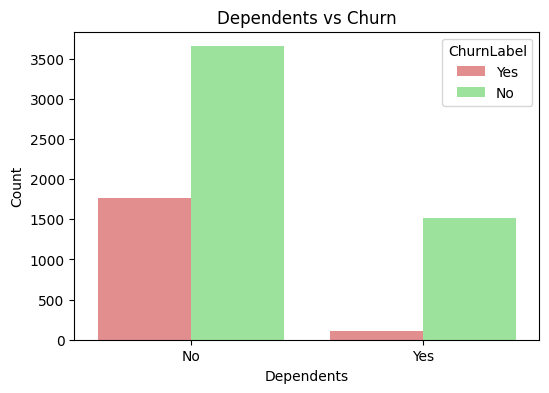

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    'Yes': 'lightcoral',
    'No': 'lightgreen'
}

plt.figure(figsize=(6,4))
sns.countplot(
    x='Dependents',
    hue='ChurnLabel',
    data=df,
    palette=palette
)

plt.title('Dependents vs Churn')
plt.xlabel('Dependents')
plt.ylabel('Count')
plt.show()

Observation: Customers without dependents account for a significantly higher number of churn cases compared to customers with dependents. This suggests that customers with dependents are more likely to remain with the company and exhibit lower churn behavior.

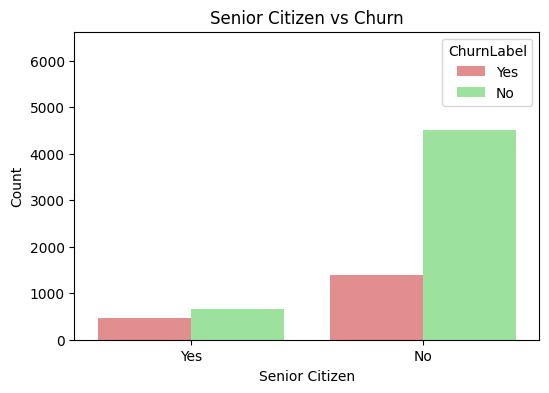

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    'Yes': 'lightcoral',
    'No': 'lightgreen'
}

plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='SeniorCitizen',
    hue='ChurnLabel',
    data=df,
    palette=palette
)

plt.title('Senior Citizen vs Churn')
plt.xlabel('Senior Citizen')
plt.ylabel('Count')

# More space above bars
plt.ylim(0, ax.get_ylim()[1] * 1.40)

plt.legend(
    title='ChurnLabel',
    loc='upper right'
)

plt.show()

Observation: Non-senior citizens represent the majority of customers and therefore account for the highest number of churn cases. However, senior citizens exhibit a comparatively higher proportion of churn within their group, suggesting that age may influence customer retention.

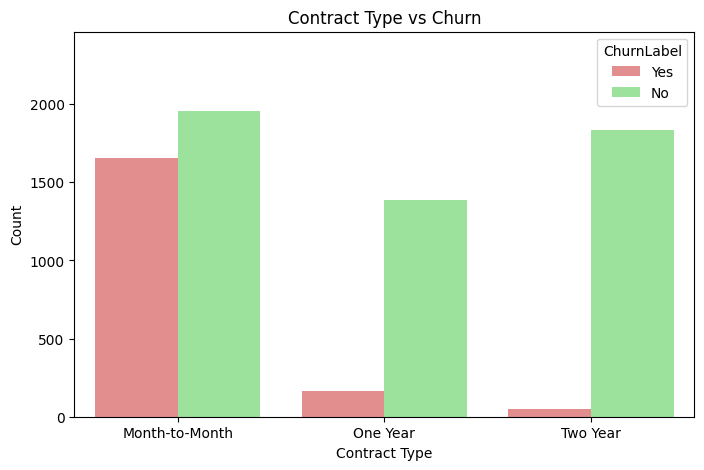

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Contract',
    hue='ChurnLabel',
    data=df,
    palette={'Yes': 'lightcoral', 'No': 'lightgreen'}
)

plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Count')

# Add extra space above bars
plt.ylim(0, ax.get_ylim()[1] * 1.20)

# Place legend neatly in upper-right
plt.legend(title='ChurnLabel', loc='upper right')

plt.show()

Observation: Customers with month-to-month contracts exhibit higher churn levels compared to customers with one-year and two-year contracts. Customers on longer-term contracts are more likely to remain with the company, suggesting that contract duration is associated with customer retention.

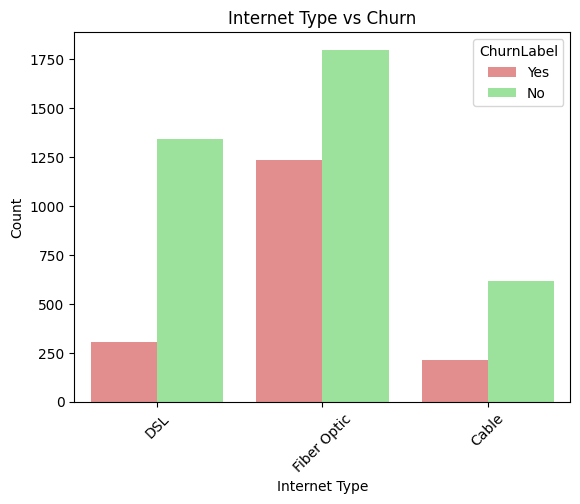

In [17]:
sns.countplot(
    x='InternetType',
    hue='ChurnLabel',
    data=df,
    palette={'Yes': 'lightcoral', 'No': 'lightgreen'}
)

plt.title('Internet Type vs Churn')
plt.xlabel('Internet Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Observation: Customers using Fiber Optic internet services exhibit higher churn levels compared to DSL and Cable users. This suggests that internet service type may influence customer churn, with Fiber Optic customers showing a greater tendency to leave the company.

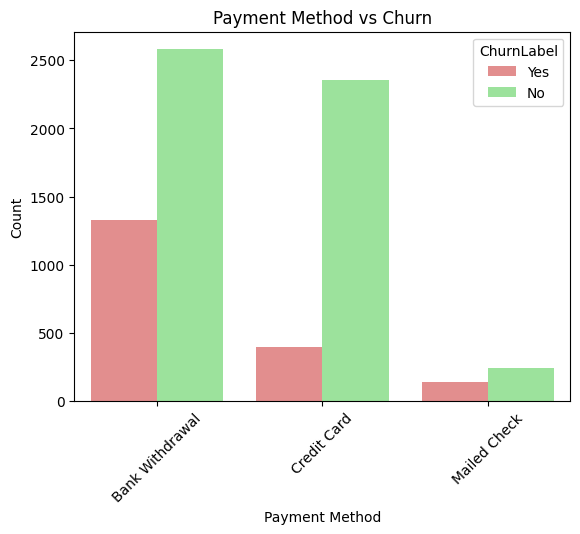

In [18]:
sns.countplot(
    x='PaymentMethod',
    hue='ChurnLabel',
    data=df,
    palette={'Yes': 'lightcoral', 'No': 'lightgreen'}
)

plt.title('Payment Method vs Churn')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Observation: Customers using Bank Withdrawal as their payment method exhibit higher churn levels compared to Credit Card and Mailed Check users. This suggests that payment method may influence customer retention, with Bank Withdrawal customers showing a greater tendency to churn.

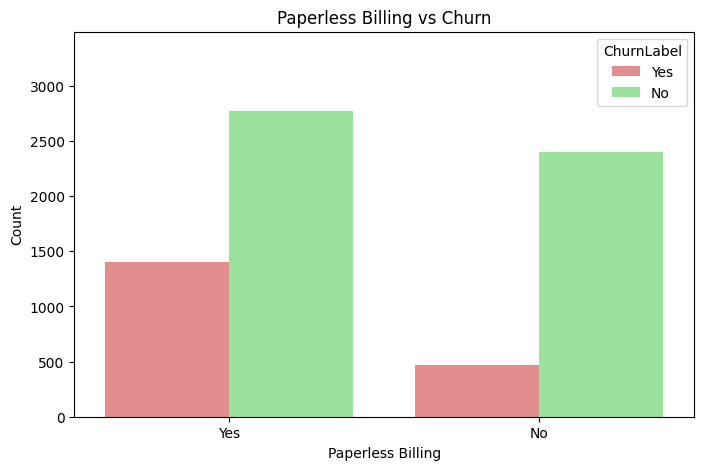

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='PaperlessBilling',
    hue='ChurnLabel',
    data=df,
    palette={'Yes': 'lightcoral', 'No': 'lightgreen'}
)

plt.title('Paperless Billing vs Churn')
plt.xlabel('Paperless Billing')
plt.ylabel('Count')

# Add space above bars
plt.ylim(0, ax.get_ylim()[1] * 1.20)

# Legend in upper right
plt.legend(title='ChurnLabel', loc='upper right')

plt.show()

Observation: Customers using paperless billing exhibit higher churn levels compared to customers who do not use paperless billing. This suggests that billing preferences may be associated with customer churn behavior.

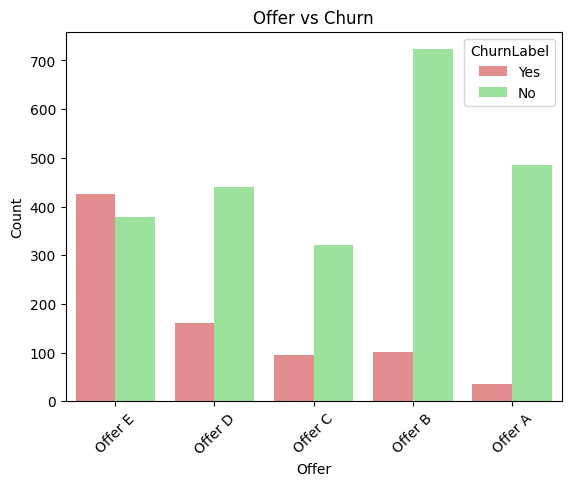

In [20]:
sns.countplot(
    x='Offer',
    hue='ChurnLabel',
    data=df,
    palette={'Yes': 'lightcoral', 'No': 'lightgreen'}
)

plt.title('Offer vs Churn')
plt.xlabel('Offer')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Observation: Customers associated with Offer A and Offer B exhibit lower churn levels, whereas customers associated with Offer E show higher churn levels. This suggests that certain promotional offers may be more effective in improving customer retention.

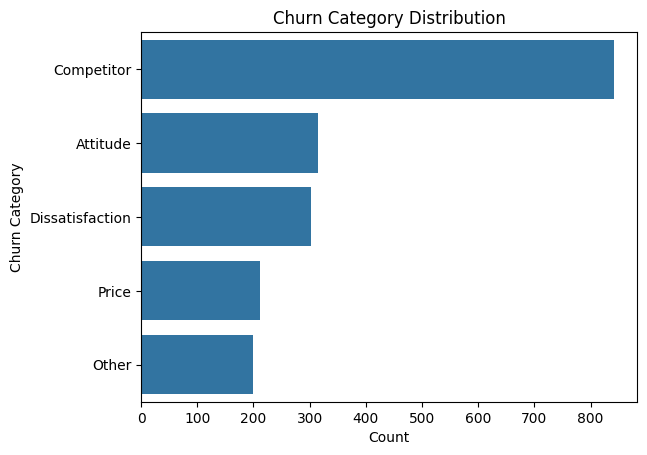

In [21]:
churned = df[df['ChurnLabel'] == 'Yes']

sns.countplot(
    y='ChurnCategory',
    data=churned,
    order=churned['ChurnCategory'].value_counts().index
)

plt.title('Churn Category Distribution')
plt.xlabel('Count')
plt.ylabel('Churn Category')
plt.show()

Observation: Competitor-related factors represent the most significant cause of customer churn, indicating that competitive offerings strongly influence customer decisions. Attitude and Dissatisfaction are also major contributors to churn, whereas Price and Other factors account for a relatively smaller proportion of customer departures.

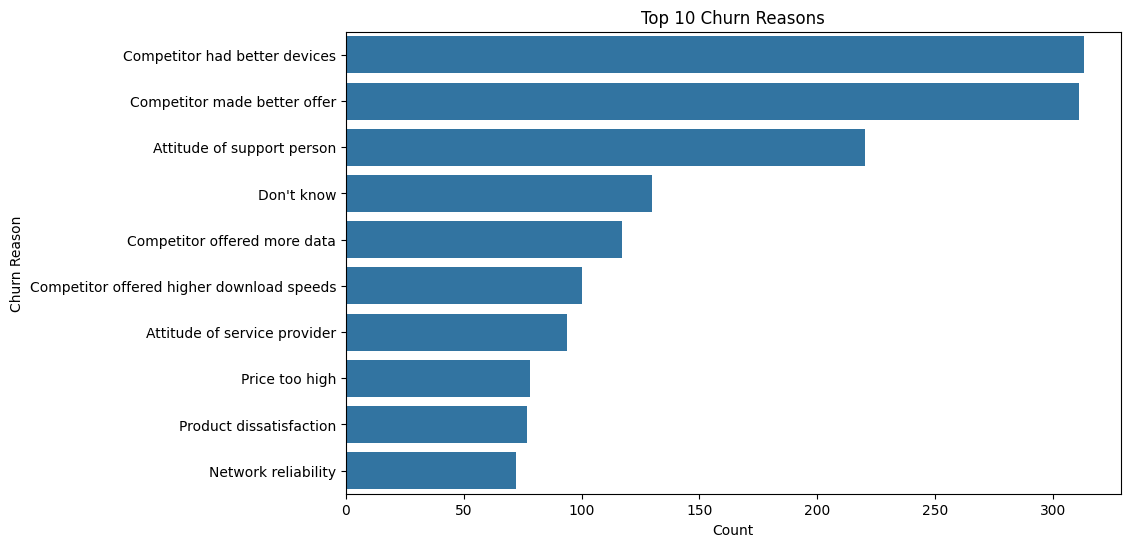

In [22]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='ChurnReason',
    data=churned,
    order=churned['ChurnReason'].value_counts().head(10).index
)

plt.title('Top 10 Churn Reasons')
plt.xlabel('Count')
plt.ylabel('Churn Reason')
plt.show()

Observation: The most common churn reasons are competitors offering better devices and better offers. Customer service-related issues, including the attitude of support personnel and service providers, also contribute significantly to customer churn. These findings indicate that both competitive market offerings and service quality are key factors influencing customer retention.

# Key Insights

- The overall customer churn rate is 26.54%.
- Customers with Month-to-Month contracts exhibit the highest churn levels.
- Fiber Optic internet users show higher churn compared to DSL and Cable users.
- Lower customer satisfaction scores are strongly associated with higher churn.
- Customers without dependents are more likely to churn than customers with dependents.
- Senior citizens exhibit a higher proportion of churn within their customer group.
- Paperless billing users show higher churn counts than non-paperless billing users.
- Bank Withdrawal customers exhibit higher churn compared to other payment methods.
- Competitor-related factors are the leading causes of customer churn.
- Better competitor offers and devices are the most common specific churn reasons.

# Conclusion

The analysis revealed that customer churn is influenced by several factors, including contract type, internet service type, satisfaction score, payment method, billing preferences, and competitive market factors. Customers with Month-to-Month contracts, Fiber Optic services, and lower satisfaction scores were more likely to churn. Competitor-related reasons emerged as the dominant drivers of customer departures. These insights can help organizations design targeted retention strategies, improve customer experience, and reduce future churn rates.

# Recommendations

- Encourage customers to switch to long-term contracts through attractive incentives.
- Improve customer satisfaction through enhanced support services.
- Review Fiber Optic service quality and pricing strategies.
- Develop retention offers for customers showing signs of churn.
- Monitor competitor offerings and provide competitive plans.
- Strengthen customer engagement programs for high-risk customer segments.

## End of Analysis
This project successfully identified key factors associated with customer churn and provided actionable insights to support customer retention strategies.